In [131]:
import numpy as np
from scipy.spatial.transform import Rotation as R

class DualQuaternion:
    """
    Minimal Dual Quaternion implementation for Rigid Body Transformations.
    Representation: q = q_real + epsilon * q_dual
    Where q_real and q_dual are quaternions [w, x, y, z].
    """
    def __init__(self, real_part, dual_part):
        self.real = np.array(real_part)
        self.dual = np.array(dual_part)

    @classmethod
    def from_pose(cls, rotation_matrix, translation_vector):
        """Creates a Dual Quaternion from a 4x4 Homogeneous matrix components."""
        # Convert rotation matrix to quaternion [x, y, z, w]
        r = R.from_matrix(rotation_matrix)
        q_rot = r.as_quat() 
        # Scipy uses [x, y, z, w], we prefer [w, x, y, z] for math clarity
        q_real = np.array([q_rot[3], q_rot[0], q_rot[1], q_rot[2]])
        
        # Translation quaternion [0, tx, ty, tz]
        t_quat = np.array([0, translation_vector[0], translation_vector[1], translation_vector[2]])
        
        # q_dual = 0.5 * t * q_real
        q_dual = 0.5 * cls.quat_multiply(t_quat, q_real)
        
        return cls(q_real, q_dual)

    def to_matrix(self):
        """Converts Dual Quaternion back to 4x4 Homogeneous Transformation Matrix."""
        # Normalize just in case
        mag = np.linalg.norm(self.real)
        q_r = self.real / mag
        q_d = self.dual / mag

        # Extract rotation
        # Scipy expects [x, y, z, w]
        scipy_quat = [q_r[1], q_r[2], q_r[3], q_r[0]]
        rot_mat = R.from_quat(scipy_quat).as_matrix()

        # Extract translation
        # t = 2 * q_dual * q_real_conjugate
        q_r_conj = np.array([q_r[0], -q_r[1], -q_r[2], -q_r[3]])
        t_q = 2 * self.quat_multiply(q_d, q_r_conj)
        trans_vec = t_q[1:] # Drop scalar part

        T = np.eye(4)
        T[:3, :3] = rot_mat
        T[:3, 3] = trans_vec
        return T

    @staticmethod
    def quat_multiply(p, q):
        """Standard quaternion multiplication."""
        # p = [pw, px, py, pz], q = [qw, qx, qy, qz]
        pw, pv = p[0], p[1:]
        qw, qv = q[0], q[1:]
        
        w = pw*qw - np.dot(pv, qv)
        v = pw*qv + qw*pv + np.cross(pv, qv)
        return np.hstack(([w], v))

    @staticmethod
    def left_operator(q):
        """
        Returns the 4x4 matrix L(q) such that L(q) * p = q * p
        """
        w, x, y, z = q
        return np.array([
            [w, -x, -y, -z],
            [x,  w, -z,  y],
            [y,  z,  w, -x],
            [z, -y,  x,  w]
        ])

    @staticmethod
    def right_operator(q):
        """
        Returns the 4x4 matrix R(q) such that R(q) * p = p * q
        """
        w, x, y, z = q
        return np.array([
            [w, -x, -y, -z],
            [x,  w,  z, -y],
            [y, -z,  w,  x],
            [z,  y, -x,  w]
        ])

def estimate_hand_eye_null_space(A_motions, B_motions):
    """
    Solves AX = XB using Dual Quaternions and Null Space Estimation.
    
    Args:
        A_motions: List of 4x4 matrices (relative robot gripper movements)
        B_motions: List of 4x4 matrices (relative camera/target movements)
        
    Returns:
        X_est: The estimated 4x4 transformation matrix.
    """
    n = len(A_motions)
    assert n == len(B_motions)
    
    # We will build a large matrix S (size 8n x 8)
    # The equation is A_dq * X_dq = X_dq * B_dq
    # Rearranged: (L(A_dq) - R(B_dq)) * X_vec = 0
    
    S_rows = []

    for i in range(n):
        # 1. Convert matrices to Dual Quaternions
        dq_a = DualQuaternion.from_pose(A_motions[i][:3, :3], A_motions[i][:3, 3])
        dq_b = DualQuaternion.from_pose(B_motions[i][:3, :3], B_motions[i][:3, 3])

        # Enforce positive scalar to avoid sign ambiguity (q and -q are same rotation)
        if dq_a.real[0] < 0:
            dq_a.real *= -1
            dq_a.dual *= -1
        if dq_b.real[0] < 0:
            dq_b.real *= -1
            dq_b.dual *= -1

        # 2. Construct Matrix Blocks
        # The dual quaternion vector is x = [x_real, x_dual]^T (8x1)
        # Multiplication A*X becomes:
        # [ L(a_real)      0      ]
        # [ L(a_dual)   L(a_real) ] * x
        
        # Multiplication X*B becomes:
        # [ R(b_real)      0      ]
        # [ R(b_dual)   R(b_real) ] * x

        L_a_real = DualQuaternion.left_operator(dq_a.real)
        L_a_dual = DualQuaternion.left_operator(dq_a.dual)
        
        R_b_real = DualQuaternion.right_operator(dq_b.real)
        R_b_dual = DualQuaternion.right_operator(dq_b.dual)

        # Block for (A * X)
        M_a = np.zeros((8, 8))
        M_a[:4, :4] = L_a_real
        M_a[4:, :4] = L_a_dual
        M_a[4:, 4:] = L_a_real

        # Block for (X * B)
        M_b = np.zeros((8, 8))
        M_b[:4, :4] = R_b_real
        M_b[4:, :4] = R_b_dual
        M_b[4:, 4:] = R_b_real

        # Constraint: (M_a - M_b) * x = 0
        Constraint = M_a - M_b
        S_rows.append(Constraint)

    # 3. Stack all constraints
    S = np.vstack(S_rows)

    # 4. Null Space Estimation via SVD
    # We solve S * x = 0
    u, s, vh = np.linalg.svd(S)
    
    
    # The solution is the last column of V (or last row of Vh)
    # corresponding to the smallest singular value
    x_solution = vh[-1]

    # 5. Reconstruct Dual Quaternion
    # x_solution is [qr0, qr1, qr2, qr3, qd0, qd1, qd2, qd3]
    x_real_est = x_solution[:4]
    x_dual_est = x_solution[4:]

    # Normalize the real part (rotation part must be unit length)
    norm_factor = np.linalg.norm(x_real_est)
    x_real_est /= norm_factor
    x_dual_est /= norm_factor # Scale dual part by same factor

    # Create estimated Dual Quaternion object
    dq_est = DualQuaternion(x_real_est, x_dual_est)
    
    return dq_est.to_matrix(), vh, S

# ==========================================
# Helpers for Simulation and Validation
# ==========================================

def get_random_transform():
    """Generates a random valid 4x4 rigid transformation."""
    # Random Rotation
    r = R.random()
    rot_mat = r.as_matrix()
    # Random Translation
    trans = np.random.uniform(-1, 1, 3)*3
    
    T = np.eye(4)
    T[:3, :3] = rot_mat
    T[:3, 3] = trans
    return T

def inverse_T(T):
    """Computes inverse of homogeneous matrix."""
    R_mat = T[:3, :3]
    t_vec = T[:3, 3]
    T_inv = np.eye(4)
    T_inv[:3, :3] = R_mat.T
    T_inv[:3, 3] = -R_mat.T @ t_vec
    return T_inv

def matrix_to_dual_quaternion(T):
    """
    Converts a 4x4 Homogeneous Transformation Matrix to a Dual Quaternion.
    
    Args:
        T (np.array): 4x4 Transformation Matrix
                      [[R, t],
                       [0, 1]]
                       
    Returns:
        tuple: (q_real, q_dual)
               Where both are numpy arrays [w, x, y, z].
    """
    # 1. Extract Rotation and Translation
    rot_mat = T[:3, :3]
    trans_vec = T[:3, 3]
    
    # 2. Convert Rotation Matrix to Real Quaternion (q_real)
    # Scipy returns [x, y, z, w], so we reorder to [w, x, y, z] for standard algebra
    r = R.from_matrix(rot_mat)
    q_scipy = r.as_quat() 
    q_real = np.array([q_scipy[3], q_scipy[0], q_scipy[1], q_scipy[2]])
    
    # Ensure q_real is normalized (numerical stability)
    q_real = q_real / np.linalg.norm(q_real)

    # 3. Create Pure Translation Quaternion (q_t)
    # Format: [0, tx, ty, tz]
    q_t = np.array([0, trans_vec[0], trans_vec[1], trans_vec[2]])
    
    # 4. Calculate Dual Part (q_dual)
    # Formula: q_dual = 0.5 * q_t * q_real
    # We define a helper for quaternion multiplication to keep this function self-contained
    q_dual = 0.5 * quat_multiply(q_t, q_real)
    
    return q_real, q_dual

def quat_multiply(p, q):
    """
    Multiplies two quaternions p and q (format [w, x, y, z]).
    """
    pw, pv = p[0], p[1:]
    qw, qv = q[0], q[1:]
    
    # Scalar part: w1*w2 - dot(v1, v2)
    w = pw*qw - np.dot(pv, qv)
    
    # Vector part: w1*v2 + w2*v1 + cross(v1, v2)
    v = pw*qv + qw*pv + np.cross(pv, qv)
    
    return np.hstack(([w], v))

def main():
    print("--- Dual Quaternion Null Space Estimation Simulation ---")
    
    # 1. Define a Ground Truth 'X' (Hand-Eye Calibration)
    # X_gt = get_random_transform()
    print("\nGround Truth X (Translation):")
    print(X_gt[:3, 3])
    
    # 2. Generate Synthetic Data
    # We simulate N movements.
    # For each movement, we have a robot pose T_gripper.
    # We need relative movements: A = T_g1^-1 * T_g2
    # B = T_c1^-1 * T_c2, where T_c = X^-1 * T_g * X isn't quite right.
    # Standard relation: A * X = X * B
    
    num_measurements = 5
    A_list = []
    B_list = []
    
    print(f"\nGenerating {num_measurements} noisy measurements...")
    
    for _ in range(num_measurements):
        # Generate a random relative movement for the robot (A)
        A = get_random_transform()
        
        # Calculate corresponding camera/object movement (B)
        # A * X = X * B  =>  B = X^-1 * A * X
        B_clean = inverse_T(X_gt) @ A @ X_gt
        
        # Generate random noise
        # Random small rotation (axis-angle perturbation)
        noise_rot_vec = np.random.normal(0, 0.000, 3) # ~0.3 degrees std dev
        R_noise = R.from_rotvec(noise_rot_vec).as_matrix()
        
        # Random small translation noise
        t_noise = np.random.normal(0, 0.000, 3) # ~5mm std dev
        
        T_noise = np.eye(4)
        T_noise[:3, :3] = R_noise
        T_noise[:3, 3] = t_noise
        
        # Apply noise: B_observed = B_clean * T_noise
        B = B_clean @ T_noise
        
        A_list.append(A)
        B_list.append(B)

    # 3. Run Estimation
    X_est, vh, SMat= estimate_hand_eye_null_space(A_list, B_list)
    readDual= matrix_to_dual_quaternion(X_gt)
    readDual= np.concatenate(readDual)
    print(readDual/np.linalg.norm(readDual[0:4]))
    print(vh[-1]/np.linalg.norm(vh[-1][0:4]))
    print(vh[-2]/np.linalg.norm(vh[-2][0:4]))
    print(np.linalg.norm(SMat@readDual))
    print(np.linalg.norm(SMat@vh[-1]))
    print(np.linalg.norm(SMat@vh[-2]))
    

if __name__ == "__main__":
    main()

--- Dual Quaternion Null Space Estimation Simulation ---

Ground Truth X (Translation):
[ 2.26604446 -1.92549889  2.09405696]

Generating 5 noisy measurements...
[ 0.00513641 -0.29858132  0.84988943  0.43417828  0.70193282 -1.30204366
 -0.80950186  0.68086258]
[-5.13641156e-03  2.98581319e-01 -8.49889426e-01 -4.34178279e-01
 -6.56107801e-01 -1.36178008e+00  8.39187720e+00  3.19270329e+00]
[ 0.00513641 -0.29858132  0.84988943  0.43417828  0.70441242 -1.44618349
 -0.39921859  0.89046171]
1.1735726724577054e-15
8.441083776018466e-15
8.178359610171234e-16


In [ ]:
X_gt = get_random_transform()
print()

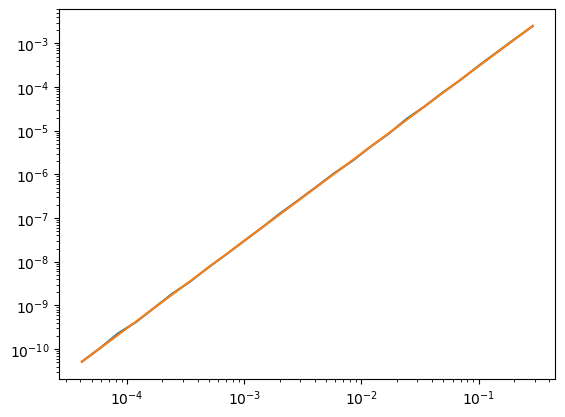

In [33]:
import matplotlib.pyplot as plt
# plt.plot(popRisks2[:])
plt.plot(Xs, popRisks[:])
plt.plot(Xs, popRisksAna[:])
plt.yscale("log")
plt.xscale("log")

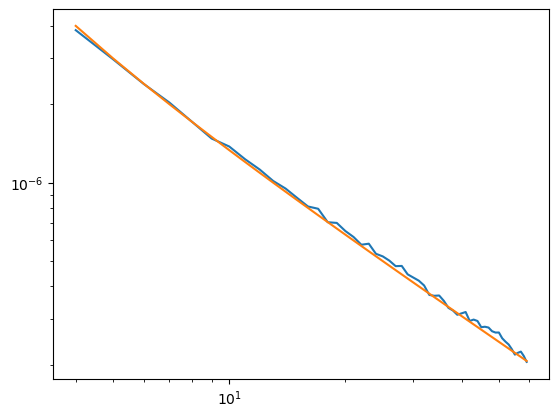

In [53]:
import matplotlib.pyplot as plt
# plt.plot(popRisks2[:])
plt.plot(Xs, popRisks[:])
plt.plot(Xs, popRisksAna[:])
plt.yscale("log")
plt.xscale("log")